<a href="https://colab.research.google.com/github/betulbilhan2/LLM-Augmentation-Fidelity/blob/main/NB10_Publication_Outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 10: Publication Outputs (Figures, Tables & LaTeX)

**Objectives:**
This is the **Synthesis Notebook**. It does not train any new models. Its sole purpose is to aggregate the results from previous notebooks and generate **publication-ready (IEEE/ACL standard) figures and tables**.

**Key Tasks (Addressing the Reviewer Checklist):**
1. **Aggregated Confusion Matrix:** Re-draw the 2x4 grid from NB08 with a **shared colorbar** to ensure standard formatting.
2. **Per-Class F1 Table:** Generate a detailed table for `Negative`, `Neutral`, and `Positive` F1 scores to support the "Neutral Class Bottleneck" discussion in the Error Analysis section.
3. **Quality Control & Retention Stats:** Aggregate retention rates from the data generation phase.
4. **LaTeX Booktabs Export:** Export all tables using the standard `booktabs` format for direct copy-pasting into Overleaf.

In [ ]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plotting style for publication
sns.set_theme(style="white", font_scale=1.1)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/tr_augmentation_project'
    IN_COLAB = True
except:
    BASE_DIR = 'C:/Users/btlbi/OneDrive/Masaustu/TR Veri arttirimi'
    IN_COLAB = False

RESULTS_DIR = os.path.join(BASE_DIR, '07_results')
EVAL_DIR = os.path.join(BASE_DIR, '08_evaluation')
PUB_DIR = os.path.join(BASE_DIR, '10_publication')

PUB_FIGS = os.path.join(PUB_DIR, 'figures')
PUB_TABLES = os.path.join(PUB_DIR, 'tables')

os.makedirs(PUB_FIGS, exist_ok=True)
os.makedirs(PUB_TABLES, exist_ok=True)

print("Directories are set up.")

Mounted at /content/drive
Directories are set up.


## 1. Load Evaluation Data

In [ ]:
data_path = os.path.join(EVAL_DIR, 'all_results_long_format.csv')
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Loaded evaluation data: {len(df)} records")
else:
    raise FileNotFoundError("Please run NB08 and NB09 first to generate all_results_long_format.csv")

levels = ['low', 'normal']
scenarios = ['E0', 'E1', 'E2', 'E3']

Loaded evaluation data: 80 records


## 2. Shared Colorbar Confusion Matrix (2x4 Grid)
In NB08, the confusion matrices had individual colorbars or a single colorbar placed arbitrarily. For publication, a unified 2x4 grid with a **single, shared colorbar** on the right side is required.

In [ ]:
# Load Ground Truth Test Labels
test_path = os.path.join(BASE_DIR, '01_splits', 'fixed', 'test.csv')
if os.path.exists(test_path):
    df_test = pd.read_csv(test_path)
    label_col = 'label' if 'label' in df_test.columns else 'sentiment'
    raw_labels = df_test[label_col]

    if pd.api.types.is_numeric_dtype(raw_labels) or all(str(x).isdigit() for x in raw_labels.dropna().unique()):
        y_true = raw_labels.astype(int).values
    else:
        label_mapping = {'Negative': 0, 'Notr': 1, 'Positive': 2, 'negative': 0, 'neutral': 1, 'positive': 2}
        y_true = raw_labels.map(label_mapping).values

    # Aggregate predictions across 10 seeds
    matrix_dict = {}
    seeds = list(range(10))

    for level in levels:
        for scen in scenarios:
            scen_preds = []
            for seed in seeds:
                expected_name = f"{level}_{scen}_seed{seed}.json"
                file_path = os.path.join(RESULTS_DIR, expected_name)
                if os.path.exists(file_path):
                    with open(file_path, 'r', encoding='utf-8') as f:
                        run_data = json.load(f)
                        scen_preds.append(run_data['predictions'])

            if len(scen_preds) > 0:
                total_cm = np.zeros((3, 3), dtype=int)
                for preds in scen_preds:
                    total_cm += confusion_matrix(y_true, preds, labels=[0, 1, 2])
                # Convert to percentages (average over 10 seeds)
                cm_avg = total_cm / len(scen_preds)
                cm_perc = cm_avg / cm_avg.sum(axis=1)[:, np.newaxis] * 100
                matrix_dict[(level, scen)] = cm_perc
else:
    print("Test file not found. Please ensure NB01 was executed.")

Saved Figure: /content/drive/MyDrive/tr_augmentation_project/10_publication/figures/fig1_shared_confusion_matrices.png


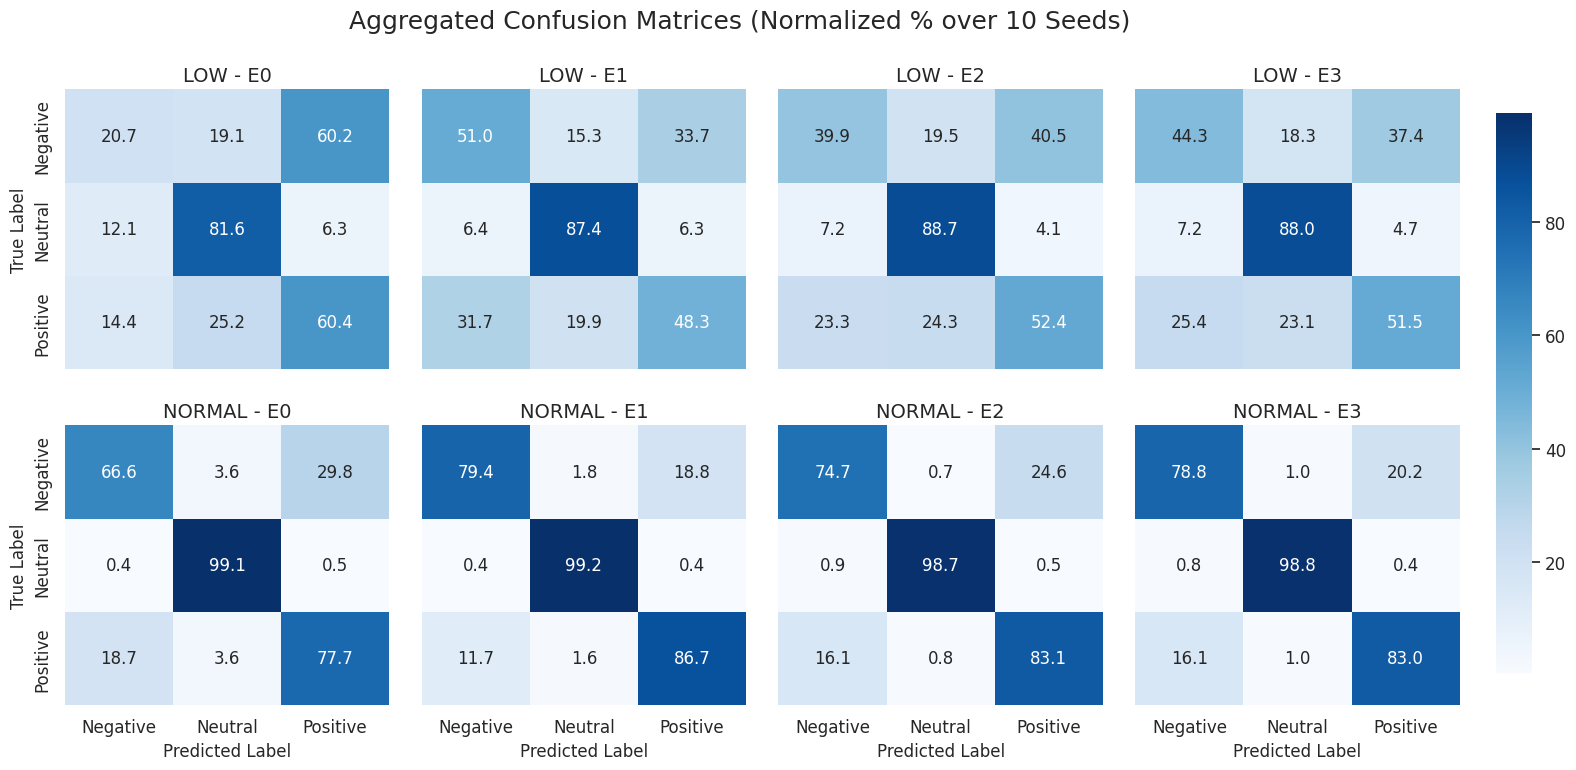

In [ ]:
if 'matrix_dict' in locals() and len(matrix_dict) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    classes = ['Negative', 'Neutral', 'Positive']

    # Find global min and max for shared colorbar
    vmin = min([cm.min() for cm in matrix_dict.values()])
    vmax = max([cm.max() for cm in matrix_dict.values()])

    # Using a single colorbar at the right
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    for i, level in enumerate(levels):
        for j, scen in enumerate(scenarios):
            ax = axes[i, j]
            key = (level, scen)
            if key in matrix_dict:
                sns.heatmap(matrix_dict[key], annot=True, fmt=".1f", cmap='Blues',
                            ax=ax, vmin=vmin, vmax=vmax, cbar=(i==0 and j==0),
                            cbar_ax=None if (i!=0 or j!=0) else cbar_ax,
                            xticklabels=classes, yticklabels=classes,
                            annot_kws={"size": 12})

                ax.set_title(f"{level.upper()} - {scen}", fontsize=14)
                if i == 1:
                    ax.set_xlabel('Predicted Label', fontsize=12)
                if j == 0:
                    ax.set_ylabel('True Label', fontsize=12)

    plt.subplots_adjust(wspace=0.1, hspace=0.2, right=0.9)
    fig.suptitle('Aggregated Confusion Matrices (Normalized % over 10 Seeds)', fontsize=18, y=0.98)

    # Save for publication
    cm_fig_path = os.path.join(PUB_FIGS, 'fig1_shared_confusion_matrices.png')
    plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved Figure: {cm_fig_path}")
    plt.show()

## 3. Per-Class F1 Table (Error Analysis)
To support the "Neutral class bottleneck" claim, we must show the F1 scores for each class separately (Negative, Neutral, Positive).

In [ ]:
# Calculate Mean +- Std for each class F1
class_f1_summary = df.groupby(['resource_level', 'scenario']).agg(
    neg_mean=('f1_negative', 'mean'), neg_std=('f1_negative', 'std'),
    neu_mean=('f1_neutral', 'mean'), neu_std=('f1_neutral', 'std'),
    pos_mean=('f1_positive', 'mean'), pos_std=('f1_positive', 'std'),
).reset_index()

class_f1_summary[r'Negative F1'] = class_f1_summary.apply(lambda r: rf"${r['neg_mean']:.4f} \\pm {r['neg_std']:.4f}$", axis=1)
class_f1_summary[r'Neutral F1'] = class_f1_summary.apply(lambda r: rf"${r['neu_mean']:.4f} \\pm {r['neu_std']:.4f}$", axis=1)
class_f1_summary[r'Positive F1'] = class_f1_summary.apply(lambda r: rf"${r['pos_mean']:.4f} \\pm {r['pos_std']:.4f}$", axis=1)

# Keep only formatted columns
formatted_class_f1 = class_f1_summary[['resource_level', 'scenario', r'Negative F1', r'Neutral F1', r'Positive F1']]

display(formatted_class_f1)

# Save as CSV
formatted_class_f1.to_csv(os.path.join(PUB_TABLES, 'per_class_f1.csv'), index=False)

# LaTeX Export with Booktabs
print("\n%% --- Per-Class F1 LaTeX Table ---")
try:
    latex_code = formatted_class_f1.style.hide(axis="index").to_latex(
        caption="Per-Class F1 Scores (Mean $\\pm$ Std over 10 Seeds)",
        label="tab:per_class_f1",
        hrules=True
    )
except AttributeError:
    try:
        latex_code = formatted_class_f1.style.hide_index().to_latex(
            caption="Per-Class F1 Scores (Mean $\\pm$ Std over 10 Seeds)",
            label="tab:per_class_f1",
            hrules=True
        )
    except AttributeError:
        latex_code = formatted_class_f1.to_latex(
            index=False,
            caption="Per-Class F1 Scores (Mean $\\pm$ Std over 10 Seeds)",
            label="tab:per_class_f1"
        )

print(latex_code)
with open(os.path.join(PUB_TABLES, 'table4_per_class_f1.tex'), 'w') as f:
    f.write(latex_code)

,resource_level,scenario,Negative F1,Neutral F1,Positive F1
0,low,E0,$0.1682 \\pm 0.1141$,$0.7164 \\pm 0.0548$,$0.6718 \\pm 0.0928$
1,low,E1,$0.3284 \\pm 0.0832$,$0.7822 \\pm 0.0668$,$0.5846 \\pm 0.1757$
2,low,E2,$0.2732 \\pm 0.1286$,$0.7632 \\pm 0.0511$,$0.6213 \\pm 0.1713$
3,low,E3,$0.3001 \\pm 0.1176$,$0.7678 \\pm 0.0821$,$0.6159 \\pm 0.1445$
4,normal,E0,$0.5240 \\pm 0.0432$,$0.9633 \\pm 0.0156$,$0.8414 \\pm 0.0351$
5,normal,E1,$0.6789 \\pm 0.0548$,$0.9808 \\pm 0.0038$,$0.9075 \\pm 0.0221$
6,normal,E2,$0.5929 \\pm 0.0362$,$0.9862 \\pm 0.0017$,$0.8804 \\pm 0.0139$
7,normal,E3,$0.6197 \\pm 0.0619$,$0.9851 \\pm 0.0022$,$0.8839 \\pm 0.0278$



%% --- Per-Class F1 LaTeX Table ---
\begin{table}
\caption{Per-Class F1 Scores (Mean $\pm$ Std over 10 Seeds)}
\label{tab:per_class_f1}
\begin{tabular}{lllll}
\toprule
resource_level & scenario & Negative F1 & Neutral F1 & Positive F1 \\
\midrule
low & E0 & $0.1682 \\pm 0.1141$ & $0.7164 \\pm 0.0548$ & $0.6718 \\pm 0.0928$ \\
low & E1 & $0.3284 \\pm 0.0832$ & $0.7822 \\pm 0.0668$ & $0.5846 \\pm 0.1757$ \\
low & E2 & $0.2732 \\pm 0.1286$ & $0.7632 \\pm 0.0511$ & $0.6213 \\pm 0.1713$ \\
low & E3 & $0.3001 \\pm 0.1176$ & $0.7678 \\pm 0.0821$ & $0.6159 \\pm 0.1445$ \\
normal & E0 & $0.5240 \\pm 0.0432$ & $0.9633 \\pm 0.0156$ & $0.8414 \\pm 0.0351$ \\
normal & E1 & $0.6789 \\pm 0.0548$ & $0.9808 \\pm 0.0038$ & $0.9075 \\pm 0.0221$ \\
normal & E2 & $0.5929 \\pm 0.0362$ & $0.9862 \\pm 0.0017$ & $0.8804 \\pm 0.0139$ \\
normal & E3 & $0.6197 \\pm 0.0619$ & $0.9851 \\pm 0.0022$ & $0.8839 \\pm 0.0278$ \\
\bottomrule
\end{tabular}
\end{table}



## 4. Quality Control & Retention Rates
This section aggregates the data filtering statistics from NB04 (e.g., how much data survived semantic filtering).
*(Note: This cell attempts to read NB04 output stats if saved. If you haven't saved them globally in a JSON, you can manually input the averages here based on NB04 output.)*

In [ ]:
qc_stats_path = os.path.join(BASE_DIR, '04_filtered', 'retention_report.csv')
if os.path.exists(qc_stats_path):
    df_qc = pd.read_csv(qc_stats_path)
    print("Quality Control Stats Loaded:")
    display(df_qc)
else:
    print("Warning: 'retention_stats.csv' not found from NB04. Please create a summary table manually in the paper if required.")
    print("You should report: Original Size -> After Similarity Filter -> After Leakage/Duplicate Filter -> Final Retention %")

Quality Control Stats Loaded:


,level,method,total_initial,total_filtered,mean_retention,mean_retention_%
0,low,backtranslation,300,246,0.820000,82.00
1,low,llm_paraphrase,300,278,0.926667,92.67
2,normal,backtranslation,3000,2479,0.826333,82.63
3,normal,llm_paraphrase,3000,2816,0.938667,93.87
